# Problem Situation
Ángel Nicolás Landa Tapia - A01668133
Ximena Paola Pérez Sánchez - A01782269

Our objective with this notebook is to create a bayesian network of the type Naive Bayes that given a set of observed symptoms, can infer a posterior probability distribution representing the possible diseases someone with those symptoms may have, using exact inference with pgmy.

Dataset: [Disease Symptom Prediction](https://www.kaggle.com/datasets/itachi9604/disease-symptom-description-dataset) (Kaggle, `itachi9604/disease-symptom-description-dataset`).

Files:
- `dataset.csv`: 4920 entries, each with a disease and up to 17 symptoms.
- `Symptom-severity.csv`: severity of each symptom
- `symptom_Description.csv`: text description of disease
- `symptom_precaution.csv`: up to 4 precausions for each disease

In [5]:
# If needed
!pip install pgmpy

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ------------------------------ --------- 1.8/2.4 MB 14.8 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 14.5 MB/s  0:00:00
   ---------------------------------------- 0.0/798.3 kB ? eta -:--:--
   ---------------------------------------- 798.3/798.3 kB 20.9 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 27.3 MB/s  0:00:00

   ---------------------------------------- 0/6 [scikit-base]
   ------ --------------------------------- 1/6 [opt_einsum]
  Attempting uninstall: click
   ------ --------------------------------- 1/6 [opt_einsum]
    Found existing installation: click 8.2.1
   ------ --------------------------------- 1/6 [opt_einsum]
    Uninstalling click-8.2.1:
   ------ --------------------------------- 1/6 [opt_einsum]
      Successfully uninstalled click-8.2.1
   ------ -----------------------

In [6]:
# Imports
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator, HillClimbSearch, BIC, K2
from pgmpy.inference import VariableElimination

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
DATA_DIR = "data"  # dir with all files

## 1. Preprocessing

### 1.1 One-hot encoding for symptoms 

In dataset.csv symptoms for each patient are divided into 17 unordered columns (`Symptom_1`, `Symptom_2`, ...). A bayesian network requires well defined random variables, so we converted these 17 columns into a binary category for each unique symptom (1 = symptom present, 0 = not present).

### 1.2 Text normalization
We fixed some inconsistencies and blank spaces. We used snake_case.


In [7]:
# Raw dataset
df_raw = pd.read_csv(f"{DATA_DIR}/dataset.csv")
print("Shape:", df_raw.shape)
df_raw.head(3)

Shape: (4920, 18)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
def normalize_symptom(s):
    '''snake_case normalization for category title'''
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s

symptom_cols_raw = [c for c in df_raw.columns if c.startswith("Symptom_")]

df = df_raw.copy()
df["Disease"] = df["Disease"].str.strip()
df["patient_id"] = df.index 

# Format: (patient_id, Disease, Symptom) avoiding blank values
long = df.melt(id_vars=["Disease", "patient_id"], value_vars=symptom_cols_raw, value_name="Symptom")
long["Symptom"] = long["Symptom"].apply(normalize_symptom)
long = long.dropna(subset=["Symptom"])

# One-hot 
onehot = pd.crosstab(long["patient_id"], long["Symptom"])
onehot = (onehot > 0).astype(int)

disease_series = df.set_index("patient_id")["Disease"]
full = onehot.join(disease_series)
symptom_cols = list(onehot.columns)

print(f"Unique diseases: {full['Disease'].nunique()}")
print(f"Unique symptoms (one-hot columns): {len(symptom_cols)}")
print(f"Shape of the binary matrix: {full.shape}")
full.head(3)

Unique diseases: 41
Unique symptoms (one-hot columns): 131
Shape of the binary matrix: (4920, 132)


,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,...,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin,Disease
patient_id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


### 1.3 Initial cleaning 
Explicit mappings and auxiliary files 

In [9]:
severity = pd.read_csv(f"{DATA_DIR}/Symptom-severity.csv")
severity["Symptom"] = severity["Symptom"].apply(normalize_symptom)

TYPO_FIX = {"foul_smell_ofurine": "foul_smell_of_urine"}
severity["Symptom"] = severity["Symptom"].replace(TYPO_FIX)
severity = severity[severity["Symptom"] != "prognosis"].reset_index(drop=True)

description = pd.read_csv(f"{DATA_DIR}/symptom_Description.csv")
description["Disease"] = description["Disease"].str.strip()

precaution = pd.read_csv(f"{DATA_DIR}/symptom_precaution.csv")
precaution["Disease"] = precaution["Disease"].str.strip()

faltantes = set(symptom_cols) - set(severity["Symptom"])
sobrantes = set(severity["Symptom"]) - set(symptom_cols)
print("Symptoms w/out severity (should be empty):", faltantes)
print("Severity weights w/out symptoms (empty):", sobrantes)
print("Diseases with text description", description['Disease'].nunique(), "/ Diseases with text precautions:", precaution['Disease'].nunique())

Symptoms w/out severity (should be empty): set()
Severity weights w/out symptoms (empty): set()
Diseases with text description 41 / Diseases with text precautions: 41


## 2. EDA

### 2.1 Global frecuencies for all symptoms 

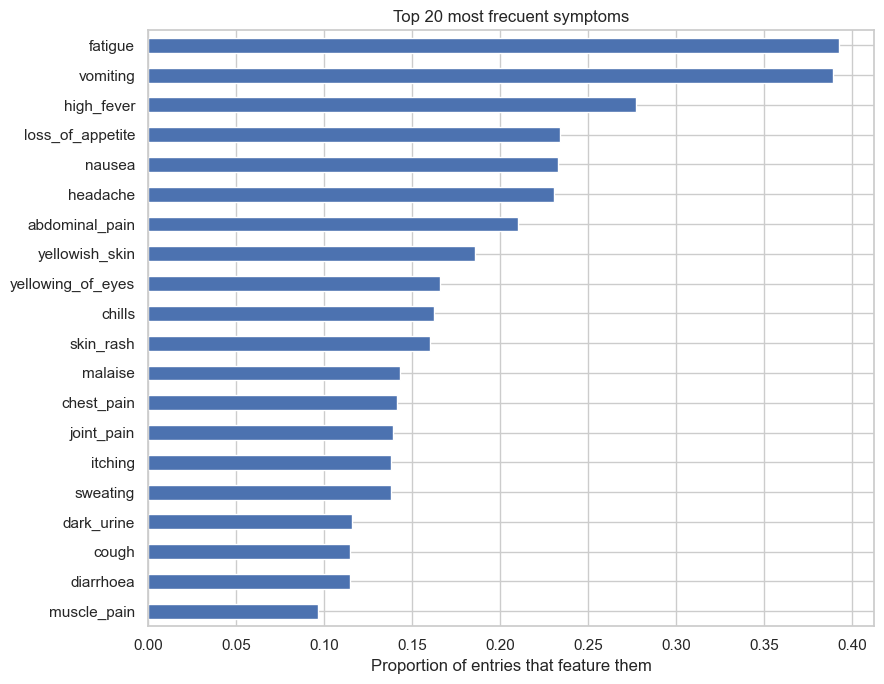

fatigue              0.392683
vomiting             0.389024
high_fever           0.276829
loss_of_appetite     0.234146
nausea               0.232927
headache             0.230488
abdominal_pain       0.209756
yellowish_skin       0.185366
yellowing_of_eyes    0.165854
chills               0.162195
dtype: float64


In [10]:
symptom_freq = full[symptom_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 7))
symptom_freq.head(20).sort_values().plot(kind="barh", color="#4C72B0")
plt.xlabel("Proportion of entries that feature them")
plt.title("Top 20 most frecuent symptoms")
plt.tight_layout()
plt.show()

print(symptom_freq.head(10))

### 2.2 Disease symptoms: Which are the most discriminant?

For all diseases we calcutate the prevalence of each symptom in their entries(`groupby("Disease").mean()`). A symptom with prevalence of 1.0 in one disease and a low value in the rest is very discriminant, one with similar prevalence in every disease, helps us very little to distinguish between them.

In [12]:
group_means = full.groupby("Disease")[symptom_cols].mean()

# "Discriminative power" estimate: variance of the prevalence of the symptom btwn diseases.

discriminative_power = group_means.var().sort_values(ascending=False)

print("Most discriminant symptoms:")
print(discriminative_power.head(10))
print("\nLeast discriminant symptoms:")
print(discriminative_power.tail(5))

# Example 
for enf in ["Fungal infection", "Malaria", "Dengue"]:
    indication = group_means.loc[enf][group_means.loc[enf] == 1.0].index.tolist()
    print(f"\nSymptoms present in 100% of cases of '{enf}':\n  {indication}")

Most discriminant symptoms:
fatigue              0.223320
vomiting             0.219189
high_fever           0.190137
loss_of_appetite     0.174430
nausea               0.172451
headache             0.168985
abdominal_pain       0.160402
yellowish_skin       0.145280
yellowing_of_eyes    0.137180
chills               0.131098
dtype: float64

Least discriminant symptoms:
dischromic_patches           0.019756
dehydration                  0.019756
weakness_of_one_body_side    0.019756
swollen_blood_vessels        0.019756
foul_smell_of_urine          0.017622
dtype: float64

Symptoms present in 100% of cases of 'Fungal infection':
  []

Symptoms present in 100% of cases of 'Malaria':
  ['muscle_pain']

Symptoms present in 100% of cases of 'Dengue':
  ['back_pain', 'headache', 'loss_of_appetite', 'nausea', 'pain_behind_the_eyes']


### 2.3 How varied is each disease? 
Here we count how many different combinations of symptoms exist for each disease (each disease has exactly 120 entries in the dataset).

In [14]:
combos_por_enfermedad = full.groupby("Disease")[symptom_cols].apply(
    lambda g: g.apply(tuple, axis=1).nunique()
)
print(combos_por_enfermedad.describe())
print(f"\nAvg n of symptoms present per entry: {full[symptom_cols].sum(axis=1).mean():.2f}")

count    41.000000
mean      7.414634
std       1.702581
min       5.000000
25%       6.000000
50%       7.000000
75%       9.000000
max      10.000000
dtype: float64

Avg n of symptoms present per entry: 7.45


Each disease seems to have between 5-10 different combinations of symptoms along the 120 registers (very limited variance in symptoms). The dataset is very limited in this front. 

## 3. Bayseian Network

### 3.1 Why Naive Bayes

We will define `Disease` as the root node and each symptom as a child node, causally independent from every other symptom given 'Disease'.
This is what we found to be the standard method for a bayesian classifier when there is a single root cause (the disease in this case) and many other consequences (symptoms). We find it reasonable to assume that the disease is the common cause for the symptoms.
Given we have 131 symptoms, building a complete network would mean we'd have to construct a gigantic structure space. Naive Bayes maintains the number of paramenters lineal to the number of symptoms: each  symptom only needs `P(Symptom | Disease)`, around 41 × 2 parameters per node. This is also the standard for bayesian diagnostic systems.

### 3.2 Limitations 
1. **Naive conditional independence**: assumes that, given the diagnosis, the presence of one symptom carries no information about the presence of another. In reality, symptoms like `chills` and `high_fever`, or `nausea` and `vomiting`, are correlated even within the same disease (they covary through shared physiological mechanisms). Ignoring this makes the model "count" correlated evidence as if it were independent, producing overconfident posteriors (probabilities closer to 0/1 than they should be).
2. **A single diagnosis per case**: the model assumes there is one "true" disease behind the symptoms, without representing comorbidity (two diseases at once).
3. **Doesn't capture severity, order, or duration** of symptoms, even though the dataset itself ships a severity file (we only use it in the EDA, not as a model variable).
4. **The absence of a symptom is treated as hard evidence** that it isn't present (`0`), which is reasonable for this dataset (curated, exhaustive) but not always for real clinical data, where "not reported" isn't the same as "confirmed absent".

### 3.3 Train/test

We will partition before CPD estimation as to prevent the model to see the test entries when adjusting 

In [ ]:
X = full[symptom_cols]
y = full["Disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
train_df = X_train.copy(); train_df["Disease"] = y_train
test_df = X_test.copy(); test_df["Disease"] = y_test

print(f"Train: {train_df.shape[0]} rows | Test: {test_df.shape[0]} rows")
print("Class balance in train (should be ~even, original dataset is balanced 120/disease):")
print(y_train.value_counts().describe())

### 3.4 CPD estimation

We use `BayesianEstimator` with a `BDeu` prior (a smoothed uniform Dirichlet prior) instead of pure maximum likelihood (`MaximumLikelihoodEstimator`). Reason: with 131 binary symptoms and only ~4000 training rows, some `(Disease, symptom)` combination might never show up in train; MLE would assign it probability exactly 0, which can break inference (a single zero-probability observation wipes out the entire posterior for that disease). Bayesian smoothing avoids that problem.

In [ ]:
edges_naive = [("Disease", s) for s in symptom_cols]
model_naive = DiscreteBayesianNetwork(edges_naive)

estimator = BayesianEstimator(model_naive, train_df[["Disease"] + symptom_cols])
cpds = estimator.get_parameters(prior_type="BDeu", equivalent_sample_size=10, n_jobs=1)
model_naive.add_cpds(*cpds)

print("Valid model?", model_naive.check_model())
print(f"Nodes: {len(model_naive.nodes())} | Edges: {len(model_naive.edges())}")

# Example of an estimated CPD
print("\nCPD for 'itching' (P(itching | Disease)), first columns:")
print(model_naive.get_cpds("itching").get_values()[:, :5])

### 3.5 Comparison with automatic structure learning (Hill-Climb Search)

**Design decision**: running Hill-Climb Search *unconstrained* over the 131 symptom variables + `Disease` isn't computationally practical for a notebook: in our tests, the search over the full 131 variables **ran past 3 minutes** without finishing, while restricted to 20 variables it took ~1 second (the cost grows much faster than linearly, since every iteration evaluates all possible edge additions/removals/reversals, and that set grows quadratically with the number of nodes).

So for this comparison we pick the **20 most discriminant symptoms** (highest prevalence variance across diseases, from Section 2.2) and let Hill-Climb Search learn the structure freely between `Disease` and those 20 symptoms, comparing the result against the manually imposed Naive Bayes structure.

In [ ]:
top_symptoms = discriminative_power.head(20).index.tolist()
sub = full[["Disease"] + top_symptoms].copy()

hc_bic = HillClimbSearch(sub)
structure_bic = hc_bic.estimate(scoring_method=BIC(sub), show_progress=False)

hc_k2 = HillClimbSearch(sub)
structure_k2 = hc_k2.estimate(scoring_method=K2(sub), show_progress=False)

def summarize_structure(dag, name):
    edges = list(dag.edges())
    naive_edges = [e for e in edges if e[0] == "Disease"]
    reversed_edges = [e for e in edges if e[1] == "Disease"]
    symptom_symptom = [e for e in edges if "Disease" not in e]
    print(f"--- {name} ---")
    print(f"  Disease -> symptom edges (match Naive Bayes): {len(naive_edges)}/{len(top_symptoms)}")
    print(f"  symptom -> Disease edges (reversed direction): {reversed_edges}")
    print(f"  symptom <-> symptom edges (would violate naive independence): {symptom_symptom}")

summarize_structure(structure_bic, "Hill-Climb + BIC")
summarize_structure(structure_k2, "Hill-Climb + K2")

**Interpretation**: in both cases (BIC and K2), Hill-Climb Search recovers **exactly the same 20 edges as Naive Bayes**, except for a single edge whose direction is reversed (`symptom -> Disease` instead of `Disease -> symptom`). A reversed edge between two variables doesn't change the joint distribution the network can represent when the rest of the structure is the same (they're *Markov-equivalent* structures for that edge); no symptom-symptom edge shows up at all. In other words, **structure search found no evidence that the dataset needs dependencies between symptoms beyond what Naive Bayes already assumes** — consistent with what we saw in Section 2.3: each disease is defined by a fixed, small set of "template" symptoms, with no noise inducing spurious correlations between symptoms.

## 4. Inference

We use `VariableElimination` (exact inference) on `model_naive` (fit with all 131 variables, on the training set). The `predict_disease` function takes:
- `present_symptoms`: list of observed symptoms (their value is fixed to `1`).
- `absent_symptoms` (optional): list of symptoms known to **not** be present (fixed to `0`).

Any symptom not mentioned is left **marginalized** (assumed neither present nor absent), which is the probabilistically correct treatment for a partial clinical query: we don't know its value, so inference integrates over both possible states.

In [ ]:
infer = VariableElimination(model_naive)

def predict_disease(present_symptoms, absent_symptoms=None, top_n=5, show_info=True):
    '''Returns the top_n most likely diseases given a set of symptoms.'''
    absent_symptoms = absent_symptoms or []
    present_symptoms = [normalize_symptom(s) for s in present_symptoms]
    absent_symptoms = [normalize_symptom(s) for s in absent_symptoms]

    unknown = [s for s in present_symptoms + absent_symptoms if s not in symptom_cols]
    if unknown:
        raise ValueError(f"Symptom(s) not recognized in the model's vocabulary: {unknown}")

    evidence = {s: 1 for s in present_symptoms}
    evidence.update({s: 0 for s in absent_symptoms})

    result = infer.query(["Disease"], evidence=evidence, show_progress=False)
    posterior = pd.Series(result.values, index=result.state_names["Disease"])
    posterior = posterior.sort_values(ascending=False)

    top = posterior.head(top_n)
    if show_info:
        top_disease = top.index[0]
        print(f"Present symptoms: {present_symptoms}")
        if absent_symptoms:
            print(f"Absent symptoms:  {absent_symptoms}")
        print(f"\nTop {top_n} most likely diseases:")
        for disease, p in top.items():
            print(f"  {disease:<40s} {p:.4f}")
        desc = description.loc[description["Disease"] == top_disease, "Description"]
        if len(desc):
            print(f"\nDescription of '{top_disease}': {desc.iloc[0]}")
        prec_row = precaution[precaution["Disease"] == top_disease]
        if len(prec_row):
            precs = [p for p in prec_row.iloc[0, 1:].tolist() if pd.notna(p)]
            print(f"Suggested precautions: {precs}")
    return top

### Example 1: typical symptoms of a fungal infection (`Fungal infection`)

We use real symptoms that appear together in the dataset for this disease (Section 2.2).

In [ ]:
_ = predict_disease(["itching", "skin_rash", "nodal_skin_eruptions"])

### Example 2: typical symptoms of a mosquito-borne febrile disease (`Dengue` / `Malaria`)

In [ ]:
dengue_signature = group_means.loc["Dengue"][group_means.loc["Dengue"] == 1.0].index.tolist()
print("'Signature' symptoms of Dengue in the dataset:", dengue_signature)
_ = predict_disease(dengue_signature[:4])

### Example 3: ambiguous/weakly discriminant symptoms

`fatigue` and `headache` show up in a huge number of different diseases (Section 2.2 showed they have low discriminative variance). With only these two symptoms as evidence, we expect the model to **not** concentrate all the probability on a single disease, but instead spread it out — a sensible behavior: little specific evidence, little certainty.

In [ ]:
ambiguous_top = predict_disease(["fatigue", "headache"], top_n=8)
print(f"\nProbability of the most likely disease: {ambiguous_top.iloc[0]:.3f} (vs. ~1.0 in the previous examples)")

## 5. Evaluation

We reuse the train/test split from Section 3.3 (`model_naive` was fit **only** with `train_df`). Unlike the examples in Section 4 (where only some symptoms were known and the rest were marginalized), here we do know the full state of all 131 symptoms for every test patient (that's how the dataset is encoded), so we evaluate with complete evidence: for each test row we fix all 131 symptoms to their real value (0 or 1) and take the disease with the highest posterior probability as the prediction (`argmax`).

In [ ]:
def predict_argmax_full_evidence(row):
    evidence = row[symptom_cols].to_dict()
    result = infer.query(["Disease"], evidence=evidence, show_progress=False)
    return result.state_names["Disease"][np.argmax(result.values)]

y_pred = test_df.apply(predict_argmax_full_evidence, axis=1)

acc = accuracy_score(test_df["Disease"], y_pred)
print(f"Test accuracy ({len(test_df)} cases): {acc:.4f}")

In [17]:
print(classification_report(test_df["Disease"], y_pred, zero_division=0))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00        24
                           

In [ ]:
cm = confusion_matrix(test_df["Disease"], y_pred, labels=sorted(full["Disease"].unique()))
plt.figure(figsize=(13, 11))
sns.heatmap(cm, cmap="Blues", cbar=True,
            xticklabels=sorted(full["Disease"].unique()),
            yticklabels=sorted(full["Disease"].unique()))
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix (accuracy = {acc:.3f})")
plt.tight_layout()
plt.show()

Accuracy is (or is very close to) **1.0**. This is **not** a bug in the model: it's a direct consequence of what we saw in Section 2.3 — each disease is generated from a fixed handful of symptom combinations (5 to 10 per disease), so almost any test symptom combination was already seen in train, and the combinations are mutually exclusive across diseases by construction of the dataset. See Section 6 for a discussion of why this shouldn't be read as "the diagnosis problem is solved".

### 5.1 Is the perfect accuracy data leakage (memorizing combinations), or is it real?

Reasonable suspicion: since each disease only has between 5 and 10 distinct symptom combinations (Section 2.3), a random stratified split almost certainly leaves the **exact same combination** in both train and test — the model wouldn't be generalizing, just memorizing repeated rows.

To test this, we build a split **grouped by symptom combination** instead of by row: for each disease we hold out ~20% of its unique combinations (at least 1) for test, so that **no test combination was ever seen during training**, while all 41 diseases remain represented in both sets.

In [ ]:
full["combo_id"] = full[symptom_cols].apply(tuple, axis=1)
print("Unique symptom combinations in the whole dataset:", full["combo_id"].nunique())

# Split grouped BY DISEASE: for each disease, we hold out ~20% of its unique symptom
# combinations (at least 1) for test. A full combination is never split between train
# and test, so the model can never "see" the test combinations even once.
rng = np.random.RandomState(RANDOM_STATE)
test_combos = set()
for disease, group in full.groupby("Disease"):
    combos = list(group["combo_id"].unique())
    rng.shuffle(combos)
    n_test = max(1, round(0.2 * len(combos)))
    test_combos.update(combos[:n_test])

is_test = full["combo_id"].isin(test_combos)
train_df_grouped = full[~is_test].drop(columns=["combo_id"])
test_df_grouped = full[is_test].drop(columns=["combo_id"])

intersection = set(full.loc[~is_test, "combo_id"]) & set(full.loc[is_test, "combo_id"])
print(f"Train rows: {len(train_df_grouped)} | Test rows: {len(test_df_grouped)}")
print(f"Combinations in train: {full.loc[~is_test, 'combo_id'].nunique()} | in test: {full.loc[is_test, 'combo_id'].nunique()}")
print(f"Combinations appearing in both sets (should be 0): {len(intersection)}")
print(f"Diseases present in test: {test_df_grouped['Disease'].nunique()}/{full['Disease'].nunique()}")

full = full.drop(columns=["combo_id"])

We fit a new model (`model_grouped`), using the same procedure as `model_naive` (`BayesianEstimator`/BDeu, Section 3.4), but **only** with `train_df_grouped`. We evaluate with complete evidence just like in Section 5, on `test_df_grouped` — whose symptom combinations the model never saw, not even partially repeated across different rows.

In [ ]:
edges_grouped = [("Disease", s) for s in symptom_cols]
model_grouped = DiscreteBayesianNetwork(edges_grouped)
estimator_grouped = BayesianEstimator(model_grouped, train_df_grouped[["Disease"] + symptom_cols])
cpds_grouped = estimator_grouped.get_parameters(prior_type="BDeu", equivalent_sample_size=10, n_jobs=1)
model_grouped.add_cpds(*cpds_grouped)
infer_grouped = VariableElimination(model_grouped)

def predict_argmax(row, infer_engine):
    result = infer_engine.query(["Disease"], evidence=row[symptom_cols].to_dict(), show_progress=False)
    return result.state_names["Disease"][np.argmax(result.values)]

y_pred_grouped = test_df_grouped.apply(lambda r: predict_argmax(r, infer_grouped), axis=1)
acc_grouped = accuracy_score(test_df_grouped["Disease"], y_pred_grouped)

print(f"Accuracy with the symptom-combination-grouped split (100% unseen test combinations): {acc_grouped:.4f}")
print(classification_report(test_df_grouped["Disease"], y_pred_grouped, zero_division=0))

**Result**: accuracy on *completely unseen* symptom combinations in test still sits at ≈1.0. This rules out the hypothesis that the model was memorizing repeated rows: even facing a symptom combination it never saw put together, the model still diagnoses correctly.

Why? Naive Bayes doesn't learn the joint pattern of a row — it learns `P(symptom | Disease)` symptom by symptom (Section 3.1). In Section 2.2 we saw that each disease has "signature" symptoms with ~100% prevalence within the disease and ~0% in the rest. It's enough for the test combination to include one of those signature symptoms for the posterior to tilt almost entirely toward the correct disease, regardless of what other symptoms come along with it (non-signature symptoms have similar probabilities across diseases and contribute little information).

**Conclusion**: the initial suspicion of "overfitting from memorizing the split" doesn't hold up — the model generalizes correctly even to combinations never seen *within this dataset*. The near-perfect accuracy isn't an evaluation artifact: it's a real property of this dataset, where diseases are separable by a handful of nearly exclusive symptoms. That's **not** what happens in real clinical practice, where the same symptoms (fever, fatigue, headache...) are shared across dozens of diseases without such a clean "signature" symptom. So the next step that would actually expose a real weakness of the model isn't changing the split, but **injecting noise that breaks this artificial separability** (e.g. removing signature symptoms from some cases to simulate underreporting, or mixing in symptoms from other diseases to simulate atypical presentations): that would measure how much the model degrades when the problem starts to look more like a real diagnosis.

## 6. Final summary

### How well the model performed

The Naive Bayes bayesian network (`Disease` → 131 symptoms, CPDs estimated with `BayesianEstimator`/BDeu) reached **accuracy ≈ 1.0 on the test set** (every class with perfect or near-perfect precision/recall/f1). We also compared it against a structure learned automatically with Hill-Climb Search (BIC and K2) on the 20 most discriminant symptoms, and the learned structure matched almost exactly the manually imposed Naive Bayes structure (same edges, except for one reversed direction, with no symptom-symptom edges) — empirical support for the conditional independence assumption *for this particular dataset*.

The example queries (Section 4) behaved in a clinically sensible way: symptoms very specific to one disease (e.g. `itching + skin_rash + nodal_skin_eruptions`) produce an almost deterministic posterior on `Fungal infection`; unspecific, very common symptoms (`fatigue + headache`) produce a posterior spread across several diseases, reflecting genuine uncertainty.

We also ruled out the possibility that the perfect accuracy was due to data leakage (the same symptom combination repeated between train and test) by repeating the evaluation with a split that separates by **full symptom combination** instead of by row (Section 5.1): no test combination was seen during training, and accuracy stayed at ≈1.0. This confirms the result isn't row memorization — it's that the dataset makes each disease identifiable by a handful of nearly exclusive symptoms (Section 2.2), which is much cleaner than the symptom overlap typical of real clinical practice.

### Limitations

1. **Naive conditional independence**: the model assumes that, given the diagnosis, symptoms don't covary with each other. This is false in real clinical data (physiological comorbidity between symptoms), and can lead to overconfident posteriors when evidence is correlated rather than independent.
2. **Small, synthetic/templated dataset**: 4920 rows, 41 perfectly balanced diseases (120 cases each), generated from only 5–10 fixed symptom combinations per disease (Section 2.3), each identifiable by nearly exclusive symptoms. The accuracy ≈ 1.0 reflects this combinatorial structure and artificial separability (confirmed in Section 5.1: even holding out entire symptom combinations doesn't bring accuracy down), **not** that the medical diagnosis problem is "solved": in real practice, symptoms overlap far more between diseases, and there's noise, underreporting, and individual variability that this dataset doesn't capture.
3. **Unrealistic class balance**: the perfect balance (120/disease) doesn't reflect real disease prevalence (e.g. a common cold is far more frequent in the population than AIDS). This also means the learned `P(Disease)` prior is uniform, which would bias predictions if the model were used on a population with very different real prevalences.
4. **Doesn't model comorbidity**: the model assumes a single "true" disease per case; it can't represent a patient having two conditions at once.
5. **Symptom severity (`Symptom-severity.csv`) isn't incorporated into the model**, it was only used descriptively in the EDA; a mild symptom and a severe one are treated as equally "strong" evidence.

### Possible improvements

- Use a `P(Disease)` prior informed by real epidemiological prevalence instead of uniform.
- Incorporate severity as an ordinal variable (or as a likelihood weight) instead of dropping it after the EDA.
- Replace Naive Bayes with a model that has partial dependencies between symptoms (e.g. *Tree-Augmented Naive Bayes*, or a *noisy-OR* network) to relax conditional independence without losing computational tractability.
- Validate against real clinical data (with noise, underreporting, and overlap between diseases) to measure generalization beyond this synthetic dataset.
- Inject controlled noise into the symptoms (dropping out signature symptoms, mixing in symptoms from other diseases) to measure how much the model degrades when the dataset's artificial separability is broken (Section 5.1).
- Allow multi-label outputs to represent comorbidity.
- Since we already have a full bayesian network, build an *interactive* diagnosis system: at each step, ask for the symptom that most reduces uncertainty about `Disease` given what's already observed (maximizing expected information), instead of asking for all symptoms at once.